In [ ]:
#%%
#   Mini Projet 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# chargement de donnees
df = pd.read_excel('pcb_dataset_1.xlsx')
n, p = df.shape
print(f"On a {n} observations, {p} variables")

# variables quantitatives
var_quant = ['resistance_ohm', 'capacitance_uF', 'temperature_test_C',
             'voltage_drop_V', 'current_leak_mA', 'signal_noise_dB',
             'power_consumption_W', 'response_time_ms']

# variable groupe pour l'ADL
col_group = 'defect'



In [ ]:
#%%
# description 
print("\nTypes des variables")
print(df.dtypes)

# on convertit les variables qualitatives en category
df['component_type'] = df['component_type'].astype('category')
df['production_line'] = df['production_line'].astype('category')
df['supplier']        = df['supplier'].astype('category')
df['defect']          = df['defect'].astype('category')
df['defect_type']     = df['defect_type'].astype('category')

print("\nSTATISTIQUES DESCRIPTIVES (variables quant)")
print(df[var_quant].describe())




Types des variables
component_id                str
component_type         category
production_line        category
supplier               category
resistance_ohm          float64
capacitance_uF          float64
temperature_test_C      float64
voltage_drop_V          float64
current_leak_mA         float64
signal_noise_dB         float64
power_consumption_W     float64
response_time_ms        float64
defect                 category
defect_type            category
dtype: object

STATISTIQUES DESCRIPTIVES (variables quant)
       resistance_ohm  capacitance_uF  temperature_test_C  voltage_drop_V  \
count    15000.000000    15000.000000        15000.000000    15000.000000   
mean       422.683639       68.979649           44.951833        3.510946   
std        453.078498      103.675612            2.968852        0.259261   
min          2.509671        0.159155           33.783161        2.873981   
25%          5.896634        0.562079           42.959070        3.312323   
50%       

In [ ]:
# On a 8 variables quantitatives 
# Ecart-type de 453ohm pour une moyenne de 422ohm et 103uF pour une moyenne de 69uF 
# Il faudra faire une analyse par type de composant car l'écart-type très élevé pour resistance_ohm et capacitance_uF (populations hétérogènes)



In [ ]:
print("\nValeurs manquantes")
print(df.isnull().sum())


Valeurs manquantes
component_id              0
component_type            0
production_line           0
supplier                  0
resistance_ohm            0
capacitance_uF            0
temperature_test_C        0
voltage_drop_V            0
current_leak_mA           0
signal_noise_dB           0
power_consumption_W       0
response_time_ms          0
defect                    0
defect_type            7779
dtype: int64


In [ ]:
# Pas de valeurs manquantes en géneral  
# C'est normal d'avoir des valeurs manquantes pour defect_type (seulement pour les composants non défectueux) 

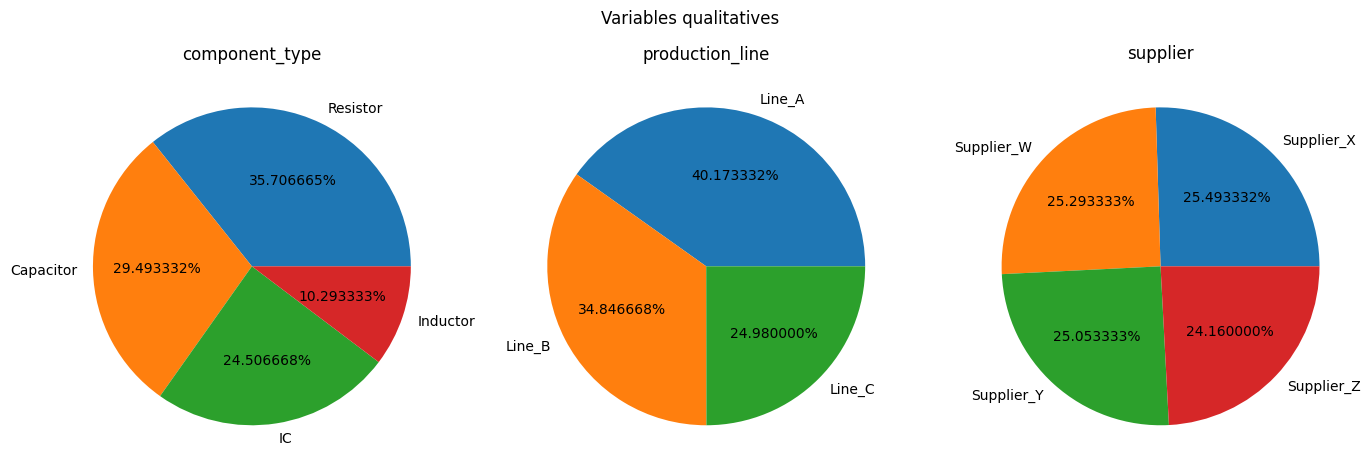

In [15]:
# Distribution des variables qualitatives - diagrammes en secteurs
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ['component_type', 'production_line', 'supplier']):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1f%%')
    ax.set_title(col)
plt.suptitle("Variables qualitatives")
plt.tight_layout()
plt.show()

In [ ]:
# Les 4 fournisseurs sont bien équilibrés pas de biais de sous-représentation

In [20]:
print("\ntaux de défauts")
print(f"Taux de défauts global : {(df['defect']=='FAIL').mean()*100}%")


taux de défauts
Taux de défauts global : 48.14%


In [ ]:
#Ce taux est  élevé pour un processus industriel mais bon pour l'ADL